# World Development Indicators: CO₂ Emissions Efficiency Analysis

This project investigates the relationship between economic development and CO₂ emissions using World Bank data.

## Objectives
- Prepare and clean WDI data
- Explore the relationship between GDP and CO₂ emissions
- Build a machine learning model to predict emissions
- Compare actual and predicted emissions
- Identify relatively efficient and inefficient countries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## 1. Load Data

We use two files from the World Development Indicators dataset:

- `WDIData.csv`: main indicator data
- `WDICountry.csv`: metadata such as region and income group

In [3]:
df = pd.read_csv("WDIData.csv")
country_df = pd.read_csv("WDICountry.csv")

print("Main dataset shape:", df.shape)
print("Country metadata shape:", country_df.shape)
df.head()

Main dataset shape: (422136, 64)
Country metadata shape: (263, 31)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,Unnamed: 63
0,Arab World,ARB,"2005 PPP conversion factor, GDP (LCU per inter...",PA.NUS.PPP.05,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"2005 PPP conversion factor, private consumptio...",PA.NUS.PRVT.PP.05,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,82.407647,82.827636,83.169227,83.587141,83.954293,84.230630,84.570425,NaN,NaN,NaN
3,Arab World,ARB,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,86.136134,86.782683,87.288244,88.389705,88.076774,88.517967,88.768654,NaN,NaN,NaN
4,Arab World,ARB,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,74.543489,75.770972,76.772916,78.839139,77.487377,78.564439,78.958780,NaN,NaN,NaN


## 2. Reshape the Dataset

The WDI dataset is originally stored in a **wide format**, where each year appears as a separate column.
For analysis and modeling, we convert it into a **long format** with one row per country-indicator-year combination.

In [4]:
year_cols = [col for col in df.columns if col.isdigit()]

df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = df_long["Year"].astype(int)

print("Long dataset shape:", df_long.shape)
df_long.head()

Long dataset shape: (24906024, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Arab World,ARB,"2005 PPP conversion factor, GDP (LCU per inter...",PA.NUS.PPP.05,1960,NaN
1,Arab World,ARB,"2005 PPP conversion factor, private consumptio...",PA.NUS.PRVT.PP.05,1960,NaN
2,Arab World,ARB,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
3,Arab World,ARB,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,Arab World,ARB,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN


## 3. Select Key Indicators

To keep the analysis focused, we use three variables:

- GDP per capita
- CO₂ emissions per capita
- Total population

In [5]:
indicators = [
    "NY.GDP.PCAP.CD",   # GDP per capita
    "EN.ATM.CO2E.PC",   # CO2 per capita
    "SP.POP.TOTL"       # Population
]

df_small = df_long[df_long["Indicator Code"].isin(indicators)].copy()

print("Filtered dataset shape:", df_small.shape)
df_small.head()

Filtered dataset shape: (46728, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
206,Arab World,ARB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1960,6.436890e-01
523,Arab World,ARB,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN
1143,Arab World,ARB,"Population, total",SP.POP.TOTL,1960,9.249093e+07
1805,Caribbean small states,CSS,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1960,1.400136e+00
2122,Caribbean small states,CSS,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,4.467034e+02


## 4. Create a Modeling Table

We pivot the filtered dataset so that each row corresponds to a country-year observation,
while the selected indicators become columns.

In [6]:
df_ml = df_small.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Indicator Code",
    values="Value"
).reset_index()

df_ml.columns.name = None
df_ml.head()

,Country Name,Country Code,Year,EN.ATM.CO2E.PC,NY.GDP.PCAP.CD,SP.POP.TOTL
0,Afghanistan,AFG,1960,0.046060,59.777327,8996351.0
1,Afghanistan,AFG,1961,0.053604,59.878153,9166764.0
2,Afghanistan,AFG,1962,0.073765,58.492874,9345868.0
3,Afghanistan,AFG,1963,0.074233,78.782758,9533954.0
4,Afghanistan,AFG,1964,0.086292,82.208444,9731361.0


## 5. Merge Country Metadata

To enrich the dataset, we merge region and income group information using `Country Code`.

In [7]:
df_ml = df_ml.merge(
    country_df[["Country Code", "Region", "Income Group"]],
    on="Country Code",
    how="left"
)

df_ml.head()

,Country Name,Country Code,Year,EN.ATM.CO2E.PC,NY.GDP.PCAP.CD,SP.POP.TOTL,Region,Income Group
0,Afghanistan,AFG,1960,0.046060,59.777327,8996351.0,South Asia,Low income
1,Afghanistan,AFG,1961,0.053604,59.878153,9166764.0,South Asia,Low income
2,Afghanistan,AFG,1962,0.073765,58.492874,9345868.0,South Asia,Low income
3,Afghanistan,AFG,1963,0.074233,78.782758,9533954.0,South Asia,Low income
4,Afghanistan,AFG,1964,0.086292,82.208444,9731361.0,South Asia,Low income


## 6. Clean Data and Create Log Features

We drop missing observations and apply log transformations to reduce skewness and improve interpretability.

In [8]:
df_ml = df_ml.dropna().copy()

df_ml["log_gdp"] = np.log1p(df_ml["NY.GDP.PCAP.CD"])
df_ml["log_co2"] = np.log1p(df_ml["EN.ATM.CO2E.PC"])
df_ml["log_pop"] = np.log1p(df_ml["SP.POP.TOTL"])

print("Final modeling dataset shape:", df_ml.shape)
df_ml.head()

Final modeling dataset shape: (8363, 11)


,Country Name,Country Code,Year,EN.ATM.CO2E.PC,NY.GDP.PCAP.CD,SP.POP.TOTL,Region,Income Group,log_gdp,log_co2,log_pop
0,Afghanistan,AFG,1960,0.046060,59.777327,8996351.0,South Asia,Low income,4.107217,0.045031,16.012330
1,Afghanistan,AFG,1961,0.053604,59.878153,9166764.0,South Asia,Low income,4.108874,0.052217,16.031095
2,Afghanistan,AFG,1962,0.073765,58.492874,9345868.0,South Asia,Low income,4.085857,0.071171,16.050445
3,Afghanistan,AFG,1963,0.074233,78.782758,9533954.0,South Asia,Low income,4.379307,0.071607,16.070370
4,Afghanistan,AFG,1964,0.086292,82.208444,9731361.0,South Asia,Low income,4.421349,0.082770,16.090864


## 7. Exploratory Data Analysis

We begin by visually inspecting the relationship between GDP per capita and CO₂ emissions.

/Users/amirhosseinlatifinavid/Desktop/Programming/statistics_project/stats_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


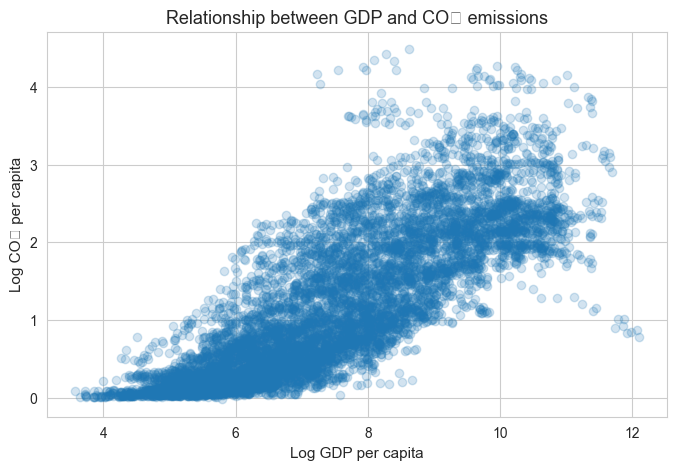

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df_ml["log_gdp"], df_ml["log_co2"], alpha=0.2)
plt.xlabel("Log GDP per capita")
plt.ylabel("Log CO₂ per capita")
plt.title("Relationship between GDP and CO₂ emissions")
plt.show()

## 8. Prepare the Machine Learning Model

We predict `log_co2` using:

- `log_gdp`
- `log_pop`
- `Year`
- `Income Group`
- `Region`

In [10]:
X = df_ml[["log_gdp", "log_pop", "Year", "Income Group", "Region"]]
y = df_ml["log_co2"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["log_gdp", "log_pop", "Year"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Income Group", "Region"])
    ]
)

In [12]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['log_gdp', 'log_pop',
                                                   'Year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Income Group',
                                                   'Region'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, n_jobs=-1,
                                       random_state=42))])

In [13]:
y_pred_rf = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results")
print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Random Forest Results
R2: 0.9317647824252148
MAE: 0.16186765159449856
RMSE: 0.24947907533236854


In [14]:
results_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "R2": [r2],
    "MAE": [mae],
    "RMSE": [rmse]
})

results_df

,Model,R2,MAE,RMSE
0,Random Forest,0.931765,0.161868,0.249479


## 10. Residual Analysis

Residuals are defined as:

**Residual = Actual log CO₂ − Predicted log CO₂**

Interpretation:

- Negative residual → lower emissions than expected
- Positive residual → higher emissions than expected

In [15]:
df_ml["predicted_log_co2"] = rf_model.predict(X)
df_ml["residual"] = df_ml["log_co2"] - df_ml["predicted_log_co2"]

df_ml.head()

,Country Name,Country Code,Year,EN.ATM.CO2E.PC,NY.GDP.PCAP.CD,SP.POP.TOTL,Region,Income Group,log_gdp,log_co2,log_pop,predicted_log_co2,residual
0,Afghanistan,AFG,1960,0.046060,59.777327,8996351.0,South Asia,Low income,4.107217,0.045031,16.012330,0.051006,-0.005975
1,Afghanistan,AFG,1961,0.053604,59.878153,9166764.0,South Asia,Low income,4.108874,0.052217,16.031095,0.051253,0.000964
2,Afghanistan,AFG,1962,0.073765,58.492874,9345868.0,South Asia,Low income,4.085857,0.071171,16.050445,0.050786,0.020385
3,Afghanistan,AFG,1963,0.074233,78.782758,9533954.0,South Asia,Low income,4.379307,0.071607,16.070370,0.051081,0.020525
4,Afghanistan,AFG,1964,0.086292,82.208444,9731361.0,South Asia,Low income,4.421349,0.082770,16.090864,0.051366,0.031405


In [16]:
year = 2013
df_year = df_ml[df_ml["Year"] == year].copy()

df_sorted = df_year.sort_values("residual")

print("Best countries:")
display(df_sorted.head(5)[["Country Name", "Region", "Income Group", "residual"]])

print("Worst countries:")
display(df_sorted.tail(5)[["Country Name", "Region", "Income Group", "residual"]])

Best countries:


,Country Name,Region,Income Group,residual
8454,"Macao SAR, China",East Asia & Pacific,High income,-1.041667
11238,Portugal,Europe & Central Asia,High income,-0.559116
7758,Latvia,Europe & Central Asia,High income,-0.523441
13374,Sweden,Europe & Central Asia,High income,-0.446057
4745,France,Europe & Central Asia,High income,-0.423682


Worst countries:


,Country Name,Region,Income Group,residual
4049,Estonia,Europe & Central Asia,High income,0.534327
691,Australia,East Asia & Pacific,High income,0.543722
9498,Mongolia,East Asia & Pacific,Lower middle income,0.642609
1735,Brunei Darussalam,East Asia & Pacific,High income,0.711995
8396,Luxembourg,Europe & Central Asia,High income,0.742168


## 11. Feature Importance

To understand what drives the model predictions, we inspect feature importance from the Random Forest model.

In [17]:
model = rf_model.named_steps["model"]
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
0,num__log_gdp,0.418175
3,cat__Income Group_High income,0.320340
1,num__log_pop,0.083402
6,cat__Income Group_Upper middle income,0.056616
2,num__Year,0.035455
8,cat__Region_Europe & Central Asia,0.028738
10,cat__Region_Middle East & North Africa,0.023789
9,cat__Region_Latin America & Caribbean,0.011769
13,cat__Region_Sub-Saharan Africa,0.007414
5,cat__Income Group_Lower middle income,0.006047


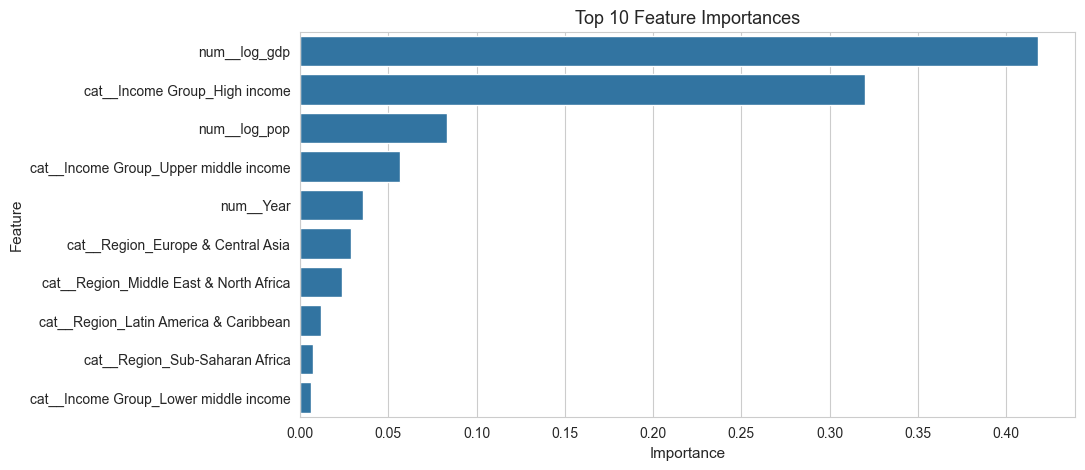

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 12. Main Findings

- GDP per capita has a strong positive relationship with CO₂ emissions.
- The Random Forest model captures non-linear patterns effectively.
- Income group is one of the strongest predictors of emissions.
- Countries with similar income levels can still differ substantially in emissions outcomes.

## 13. Dashboard

An interactive dashboard was also developed separately in:

`wdi_co2_dashboard_app.py`

This dashboard includes maps, country filters, scatter plots, and country-level comparisons.

## 14. Final Conclusion

This project shows that economic growth is strongly associated with emissions, but GDP alone is not sufficient to explain cross-country differences.

Structural characteristics such as income group, region, and broader development patterns play a major role in shaping emissions outcomes.